# Learning Visually-Grounded Speech Models with Noisy Data

**Task (80%)**: Train a speech-to-image retrieval model on the Flickr Audio Captions Corpus.  
Simulate data misalignment by randomly swapping audio-image pairs at various rates (0%–50%).  
Measure retrieval performance (Recall@1, R@5, R@10) as a function of misalignment rate.

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.io import wavfile
from scipy.signal import resample_poly
from math import gcd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Paths ──
PROJECT_ROOT = os.path.normpath('..')
DATA_ROOT = os.path.join(PROJECT_ROOT, 'data')
RAW_ROOT = os.path.join(DATA_ROOT, 'raw')
META_ROOT = os.path.join(DATA_ROOT, 'metadata')
ARTIFACTS_ROOT = os.path.join(PROJECT_ROOT, 'artifacts')

WAV2CAPT_PATH = os.path.join(META_ROOT, 'wav2capt.txt')
IMAGE_FEATURES_PATH = os.path.join(ARTIFACTS_ROOT, 'image_features.pt')
CACHE_PATH = os.path.join(ARTIFACTS_ROOT, 'mel_cache.pt')
AUDIO_DIR = os.path.join(RAW_ROOT, 'flickr_audio', 'flickr_audio', 'wavs')

# ── Config ──
EMBED_DIM = 256
N_MELS = 40
MAX_FRAMES = 1024     
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 15
SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Device: {DEVICE}")
print(f"Project root: {os.path.abspath(PROJECT_ROOT)}")

Device: cuda
Project root: d:\Deep Learning


## 1. Data Preparation

Load `wav2capt.txt` mappings and pre-extracted image features.  
Split by image into train (6000), val (1000), test (1000).

In [2]:
# Load wav → image mappings
pairs = []
with open(WAV2CAPT_PATH) as f:
    for line in f:
        parts = line.strip().split()
        pairs.append((parts[0], parts[1]))   # (wav_file, img_file)

# Load pre-extracted image features (ResNet-50, 2048-dim)
image_features = torch.load(IMAGE_FEATURES_PATH, weights_only=False)

# Split by unique images
all_images = sorted(set(img for _, img in pairs))
random.shuffle(all_images)

train_imgs = set(all_images[:6000])
val_imgs = set(all_images[6000:7000])
test_imgs = set(all_images[7000:])

train_pairs = [(w, i) for w, i in pairs if i in train_imgs]
val_pairs = [(w, i) for w, i in pairs if i in val_imgs]
test_pairs = [(w, i) for w, i in pairs if i in test_imgs]

print(f"Train: {len(train_pairs)} pairs ({len(train_imgs)} images)")
print(f"Val:   {len(val_pairs)} pairs ({len(val_imgs)} images)")
print(f"Test:  {len(test_pairs)} pairs ({len(test_imgs)} images)")

Train: 30000 pairs (6000 images)
Val:   5000 pairs (1000 images)
Test:  5000 pairs (1000 images)


In [3]:
def apply_misalignment(pairs, rate, image_pool):
    """Randomly swap the image in each pair with probability `rate`."""
    if rate == 0:
        return pairs[:]
    img_list = list(image_pool)
    noisy = []
    for wav, img in pairs:
        if random.random() < rate:
            new_img = random.choice(img_list)
            while new_img == img:
                new_img = random.choice(img_list)
            noisy.append((wav, new_img))
        else:
            noisy.append((wav, img))
    return noisy

## 2. Dataset

Each sample loads a WAV file, computes the mel spectrogram, and returns it paired with the pre-extracted image feature vector.

In [3]:
def create_mel_filterbank(sr, n_fft, n_mels):
    """Create a mel filterbank matrix (n_mels, n_fft//2 + 1)."""
    f_min, f_max = 0.0, sr / 2.0
    n_freqs = n_fft // 2 + 1

    def hz_to_mel(f):
        return 2595.0 * np.log10(1.0 + f / 700.0)

    def mel_to_hz(m):
        return 700.0 * (10.0 ** (m / 2595.0) - 1.0)

    mel_min = hz_to_mel(f_min)
    mel_max = hz_to_mel(f_max)
    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sr).astype(int)

    fbank = np.zeros((n_mels, n_freqs))
    for i in range(n_mels):
        for j in range(bins[i], bins[i + 1]):
            fbank[i, j] = (j - bins[i]) / (bins[i + 1] - bins[i])
        for j in range(bins[i + 1], bins[i + 2]):
            fbank[i, j] = (bins[i + 2] - j) / (bins[i + 2] - bins[i + 1])
    return fbank.astype(np.float32)


def compute_mel_spectrogram(waveform, sr, n_fft=1024, hop_length=512,
                            n_mels=40, mel_fb=None):
    """Compute log-mel spectrogram from a 1-D numpy waveform."""
    if len(waveform) < n_fft:
        waveform = np.pad(waveform, (0, n_fft - len(waveform)))
    window = np.hanning(n_fft).astype(np.float32)

    num_frames = 1 + (len(waveform) - n_fft) // hop_length
    frames = np.lib.stride_tricks.as_strided(
        waveform,
        shape=(num_frames, n_fft),
        strides=(waveform.strides[0] * hop_length, waveform.strides[0]),
    ).copy()
    frames = frames * window
    spectrum = np.fft.rfft(frames, n=n_fft)
    power = np.abs(spectrum) ** 2

    if mel_fb is None:
        mel_fb = create_mel_filterbank(sr, n_fft, n_mels)

    mel = power @ mel_fb.T
    mel = np.log(mel + 1e-9)
    return mel.T.astype(np.float32)  # (n_mels, T)


def load_wav(path, target_sr=16000):
    """Load a WAV file and resample to target_sr. Returns float32 1-D array."""
    sr, data = wavfile.read(path)
    if data.dtype == np.int16:
        data = data.astype(np.float32) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float32) / 2147483648.0
    elif data.dtype != np.float32:
        data = data.astype(np.float32)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if sr != target_sr:
        g = gcd(sr, target_sr)
        data = resample_poly(data, target_sr // g, sr // g).astype(np.float32)
    return data, target_sr


# ── Pre-compute & cache all mel spectrograms (one-time cost) ──
MEL_FB = create_mel_filterbank(16000, 1024, N_MELS)

if os.path.exists(CACHE_PATH):
    print("Loading cached mel spectrograms...")
    mel_cache = torch.load(CACHE_PATH, weights_only=False)
    print(f"Loaded {len(mel_cache)} cached spectrograms.")
else:
    print("Pre-computing mel spectrograms for all 40k audio files...")
    all_wavs = sorted(set(w for w, _ in pairs))
    mel_cache = {}
    for i, wav_file in enumerate(tqdm(all_wavs, desc="Computing mels")):
        waveform, sr = load_wav(os.path.join(AUDIO_DIR, wav_file), 16000)
        mel = compute_mel_spectrogram(waveform, sr, mel_fb=MEL_FB)
        mel = torch.from_numpy(mel)  # (n_mels, T)
        # Pad / truncate
        if mel.shape[1] > MAX_FRAMES:
            mel = mel[:, :MAX_FRAMES]
        else:
            mel = F.pad(mel, (0, MAX_FRAMES - mel.shape[1]))
        mel_cache[wav_file] = mel
    torch.save(mel_cache, CACHE_PATH)
    print(f"Saved {len(mel_cache)} spectrograms to {CACHE_PATH}")


class FlickrAudioDataset(Dataset):
    """Training dataset: returns cached mel + image feature."""
    def __init__(self, pairs, image_features, mel_cache):
        self.pairs = pairs
        self.image_features = image_features
        self.mel_cache = mel_cache

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        wav_file, img_file = self.pairs[idx]
        return self.mel_cache[wav_file], self.image_features[img_file], img_file


class FlickrEvalDataset(Dataset):
    """Eval dataset: returns cached mel + image filename."""
    def __init__(self, pairs, mel_cache):
        self.pairs = pairs
        self.mel_cache = mel_cache

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        wav_file, img_file = self.pairs[idx]
        return self.mel_cache[wav_file], img_file

Loading cached mel spectrograms...
Loaded 40000 cached spectrograms.


## 3. Model

- **AudioEncoder**: 1-D CNN over mel spectrograms → 256-dim embedding  
- **ImageProjector**: 2-layer MLP projecting 2048-dim ResNet features → 256-dim  
- **Contrastive loss**: symmetric InfoNCE (CLIP-style) with learnable temperature

In [5]:
class AudioEncoder(nn.Module):
    def __init__(self, n_mels, embed_dim, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_mels, 128, 3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Dropout(dropout),
            nn.Conv1d(128, 256, 3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2),
            nn.Dropout(dropout),
            nn.Conv1d(256, 512, 3, padding=1),
            nn.BatchNorm1d(512), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, embed_dim),
        )

    def forward(self, x):          # x: (B, n_mels, T)
        x = self.conv(x)           # (B, 512, 1)
        x = x.squeeze(-1)          # (B, 512)
        return self.fc(x)          # (B, embed_dim)


class ImageProjector(nn.Module):
    def __init__(self, input_dim, embed_dim, dropout=0.2):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, x):
        return self.mlp(x)


class SpeechImageModel(nn.Module):
    def __init__(self, n_mels=40, img_feat_dim=2048, embed_dim=256):
        super().__init__()
        self.audio_encoder = AudioEncoder(n_mels, embed_dim)
        self.image_projector = ImageProjector(img_feat_dim, embed_dim)
        self.log_temperature = nn.Parameter(torch.tensor(np.log(1 / 0.07)))

    def forward(self, mel, img_feat):
        a = F.normalize(self.audio_encoder(mel), dim=1)
        v = F.normalize(self.image_projector(img_feat), dim=1)
        return a, v

    def contrastive_loss(self, a, v):
        temp = self.log_temperature.exp()
        logits = a @ v.T * temp
        labels = torch.arange(len(a), device=a.device)
        return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

## 4. Training & Evaluation

- **Training**: Adam optimiser, contrastive loss, 15 epochs.  
- **Evaluation**: speech-to-image retrieval — Recall@1, R@5, R@10 on the clean test set.

In [6]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for mel, img_feat, _ in loader:
        mel, img_feat = mel.to(device), img_feat.to(device)
        a, v = model(mel, img_feat)
        loss = model.contrastive_loss(a, v)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * mel.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_recall(model, eval_loader, image_features, test_images, device):
    """Compute Recall@1, @5, @10 for speech → image retrieval."""
    model.eval()

    # 1. Embed all test audio
    audio_embs, img_labels = [], []
    for mel, img_file in eval_loader:
        mel = mel.to(device)
        a = F.normalize(model.audio_encoder(mel), dim=1)
        audio_embs.append(a.cpu())
        img_labels.extend(img_file)
    audio_embs = torch.cat(audio_embs)                  # (N_audio, D)

    # 2. Embed all unique test images
    unique_imgs = sorted(test_images)
    img_feats = torch.stack([image_features[im] for im in unique_imgs]).to(device)
    img_embs = F.normalize(model.image_projector(img_feats), dim=1).cpu()  # (N_img, D)

    # 3. Similarity & recall
    sim = audio_embs @ img_embs.T                       # (N_audio, N_img)
    img2idx = {im: i for i, im in enumerate(unique_imgs)}

    recalls = {1: 0, 5: 0, 10: 0}
    for i, img_name in enumerate(img_labels):
        gt = img2idx[img_name]
        ranked = sim[i].argsort(descending=True)
        rank = (ranked == gt).nonzero(as_tuple=True)[0].item()
        for k in recalls:
            if rank < k:
                recalls[k] += 1
    n = len(img_labels)
    return {k: v / n for k, v in recalls.items()}

In [7]:
def run_experiment(misalignment_rate, train_pairs, val_pairs, test_pairs,
                   train_imgs, test_imgs, image_features, mel_cache):
    """Train a model at the given misalignment rate and return test recalls."""
    print(f"\n{'='*60}")
    print(f"  Misalignment rate = {misalignment_rate*100:.0f}%")
    print(f"{'='*60}")

    # Apply misalignment to training data only
    noisy_train = apply_misalignment(train_pairs, misalignment_rate, train_imgs)

    # Datasets & loaders (num_workers=0 to avoid Windows multiprocessing issues)
    train_ds = FlickrAudioDataset(noisy_train, image_features, mel_cache)
    val_ds   = FlickrEvalDataset(val_pairs, mel_cache)
    test_ds  = FlickrEvalDataset(test_pairs, mel_cache)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)

    # Model & optimiser with weight decay + cosine LR schedule
    model = SpeechImageModel(N_MELS, 2048, EMBED_DIM).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_r10 = 0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        scheduler.step()
        val_recalls = evaluate_recall(model, val_loader, image_features,
                                      val_imgs, DEVICE)
        print(f"  Epoch {epoch:2d}  loss={loss:.4f}  "
              f"val R@1={val_recalls[1]:.4f}  R@5={val_recalls[5]:.4f}  "
              f"R@10={val_recalls[10]:.4f}")

        if val_recalls[10] > best_r10:
            best_r10 = val_recalls[10]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Evaluate best model on test set
    model.load_state_dict(best_state)
    model.to(DEVICE)
    test_recalls = evaluate_recall(model, test_loader, image_features,
                                   test_imgs, DEVICE)
    print(f"  ► Test  R@1={test_recalls[1]:.4f}  R@5={test_recalls[5]:.4f}  "
          f"R@10={test_recalls[10]:.4f}")
    return test_recalls

## 5. Misalignment Experiments

Train separate models at misalignment rates 0%, 10%, 20%, 30%, 40%, 50%.  
Each model is evaluated on the **clean** test set.

In [8]:
misalignment_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
results = {}

for rate in misalignment_rates:
    recalls = run_experiment(rate, train_pairs, val_pairs, test_pairs,
                             train_imgs, test_imgs, image_features, mel_cache)
    results[rate] = recalls


  Misalignment rate = 0%
  Epoch  1  loss=4.0539  val R@1=0.0024  R@5=0.0102  R@10=0.0232
  Epoch  2  loss=3.7948  val R@1=0.0038  R@5=0.0184  R@10=0.0322
  Epoch  3  loss=3.6018  val R@1=0.0070  R@5=0.0264  R@10=0.0442
  Epoch  4  loss=3.3585  val R@1=0.0088  R@5=0.0460  R@10=0.0792
  Epoch  5  loss=3.0969  val R@1=0.0146  R@5=0.0600  R@10=0.1050
  Epoch  6  loss=2.8448  val R@1=0.0220  R@5=0.0786  R@10=0.1328
  Epoch  7  loss=2.6040  val R@1=0.0240  R@5=0.0934  R@10=0.1516
  Epoch  8  loss=2.3866  val R@1=0.0276  R@5=0.1012  R@10=0.1726
  Epoch  9  loss=2.2060  val R@1=0.0304  R@5=0.1082  R@10=0.1788
  Epoch 10  loss=2.0501  val R@1=0.0330  R@5=0.1162  R@10=0.1898
  Epoch 11  loss=1.9382  val R@1=0.0328  R@5=0.1208  R@10=0.1960
  Epoch 12  loss=1.8276  val R@1=0.0374  R@5=0.1226  R@10=0.1962
  Epoch 13  loss=1.7438  val R@1=0.0396  R@5=0.1242  R@10=0.2066
  Epoch 14  loss=1.6986  val R@1=0.0388  R@5=0.1262  R@10=0.2060
  Epoch 15  loss=1.6726  val R@1=0.0394  R@5=0.1268  R@10=0.2066

## 6. Results

Plot Recall@1, R@5, R@10 as a function of misalignment rate.

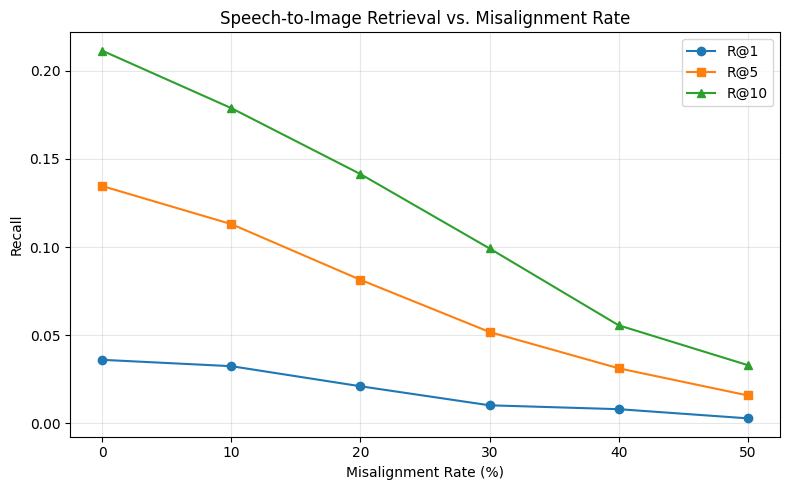

  Rate     R@1     R@5    R@10
------------------------------
    0%  0.0360  0.1346  0.2114
   10%  0.0324  0.1130  0.1788
   20%  0.0210  0.0814  0.1414
   30%  0.0102  0.0518  0.0992
   40%  0.0080  0.0312  0.0556
   50%  0.0028  0.0158  0.0330


In [9]:
rates  = sorted(results.keys())
r1     = [results[r][1]  for r in rates]
r5     = [results[r][5]  for r in rates]
r10    = [results[r][10] for r in rates]

plt.figure(figsize=(8, 5))
plt.plot([r*100 for r in rates], r1,  'o-', label='R@1')
plt.plot([r*100 for r in rates], r5,  's-', label='R@5')
plt.plot([r*100 for r in rates], r10, '^-', label='R@10')
plt.xlabel('Misalignment Rate (%)')
plt.ylabel('Recall')
plt.title('Speech-to-Image Retrieval vs. Misalignment Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print table
print(f"{'Rate':>6s}  {'R@1':>6s}  {'R@5':>6s}  {'R@10':>6s}")
print('-' * 30)
for r in rates:
    print(f"{r*100:5.0f}%  {results[r][1]:6.4f}  {results[r][5]:6.4f}  {results[r][10]:6.4f}")

## 6b. Extended Analysis

- **Relative performance drop** vs. misalignment rate  
- **Grouped bar chart** comparing R@1, R@5, R@10 side-by-side  
- **Performance retention heatmap** (% of clean performance retained)  
- **Random baseline comparison** to show how far above chance we are

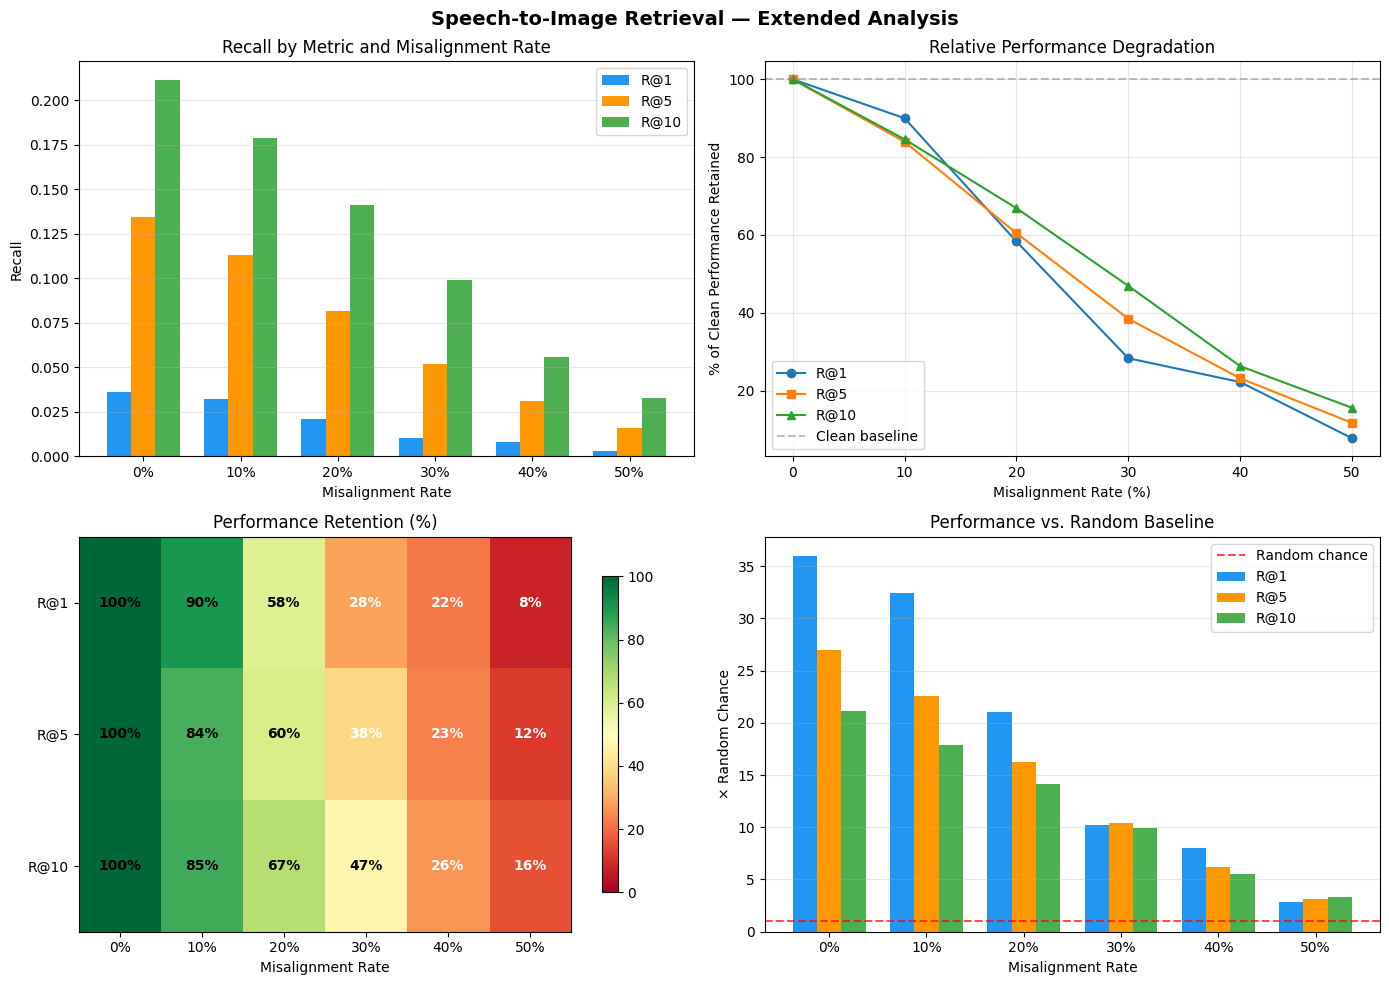

  Rate     R@1     R@5    R@10  R@10 drop   ×Random
-----------------------------------------------------------------
    0%  0.0360  0.1346  0.2114      +0.0%     21.1×
   10%  0.0324  0.1130  0.1788     +15.4%     17.9×
   20%  0.0210  0.0814  0.1414     +33.1%     14.1×
   30%  0.0102  0.0518  0.0992     +53.1%      9.9×
   40%  0.0080  0.0312  0.0556     +73.7%      5.6×
   50%  0.0028  0.0158  0.0330     +84.4%      3.3×
-----------------------------------------------------------------
Random baseline: R@1=0.0010  R@5=0.0050  R@10=0.0100
Even at 50% misalignment, R@10 is 3.3× above random chance.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rates  = sorted(results.keys())
r1     = [results[r][1]  for r in rates]
r5     = [results[r][5]  for r in rates]
r10    = [results[r][10] for r in rates]
pct_labels = [f"{r*100:.0f}%" for r in rates]

# ── 1. Grouped bar chart ──
ax = axes[0, 0]
x = np.arange(len(rates))
w = 0.25
ax.bar(x - w, r1, w, label='R@1', color='#2196F3')
ax.bar(x,     r5, w, label='R@5', color='#FF9800')
ax.bar(x + w, r10, w, label='R@10', color='#4CAF50')
ax.set_xticks(x)
ax.set_xticklabels(pct_labels)
ax.set_xlabel('Misalignment Rate')
ax.set_ylabel('Recall')
ax.set_title('Recall by Metric and Misalignment Rate')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ── 2. Relative performance drop (% of clean baseline retained) ──
ax = axes[0, 1]
base_r1, base_r5, base_r10 = r1[0], r5[0], r10[0]
rel_r1  = [v / base_r1  * 100 for v in r1]
rel_r5  = [v / base_r5  * 100 for v in r5]
rel_r10 = [v / base_r10 * 100 for v in r10]
ax.plot([r*100 for r in rates], rel_r1,  'o-', label='R@1')
ax.plot([r*100 for r in rates], rel_r5,  's-', label='R@5')
ax.plot([r*100 for r in rates], rel_r10, '^-', label='R@10')
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='Clean baseline')
ax.set_xlabel('Misalignment Rate (%)')
ax.set_ylabel('% of Clean Performance Retained')
ax.set_title('Relative Performance Degradation')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 3. Performance retention heatmap ──
ax = axes[1, 0]
retention = np.array([rel_r1, rel_r5, rel_r10])
im = ax.imshow(retention, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(rates)))
ax.set_xticklabels(pct_labels)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['R@1', 'R@5', 'R@10'])
ax.set_xlabel('Misalignment Rate')
ax.set_title('Performance Retention (%)')
for i in range(3):
    for j in range(len(rates)):
        ax.text(j, i, f"{retention[i, j]:.0f}%", ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if retention[i, j] < 40 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)

# ── 4. Multiplier over random baseline ──
ax = axes[1, 1]
n_test_images = len(test_imgs)  # 1000
random_r1  = 1  / n_test_images
random_r5  = 5  / n_test_images
random_r10 = 10 / n_test_images
mult_r1  = [v / random_r1  for v in r1]
mult_r5  = [v / random_r5  for v in r5]
mult_r10 = [v / random_r10 for v in r10]
ax.bar(x - w, mult_r1, w, label='R@1', color='#2196F3')
ax.bar(x,     mult_r5, w, label='R@5', color='#FF9800')
ax.bar(x + w, mult_r10, w, label='R@10', color='#4CAF50')
ax.axhline(1, color='red', linestyle='--', alpha=0.7, label='Random chance')
ax.set_xticks(x)
ax.set_xticklabels(pct_labels)
ax.set_xlabel('Misalignment Rate')
ax.set_ylabel('× Random Chance')
ax.set_title('Performance vs. Random Baseline')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Speech-to-Image Retrieval — Extended Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary statistics ──
print("=" * 65)
print(f"{'Rate':>6}  {'R@1':>6}  {'R@5':>6}  {'R@10':>6}  {'R@10 drop':>9}  {'×Random':>8}")
print("-" * 65)
for i, r in enumerate(rates):
    drop = (1 - r10[i] / base_r10) * 100
    mult = r10[i] / random_r10
    print(f"{r*100:5.0f}%  {r1[i]:6.4f}  {r5[i]:6.4f}  {r10[i]:6.4f}  "
          f"{drop:+8.1f}%  {mult:7.1f}×")
print("-" * 65)
print(f"Random baseline: R@1={random_r1:.4f}  R@5={random_r5:.4f}  R@10={random_r10:.4f}")
print(f"Even at 50% misalignment, R@10 is {r10[-1]/random_r10:.1f}× above random chance.")

## 6c. Deeper Analysis

Train a clean (0%) model to inspect:
1. **t-SNE embedding space** — do audio & image embeddings cluster by semantic content?
2. **Cosine similarity distributions** — matched vs. unmatched pairs
3. **Rank distribution** — histogram of the rank of the correct image
4. **Audio duration vs. retrieval success** — are shorter/longer clips easier to retrieve?

In [12]:
from sklearn.manifold import TSNE

# ── Train a clean model for embedding analysis ──
print("Training a clean model for embedding analysis...")
clean_ds = FlickrAudioDataset(train_pairs, image_features, mel_cache)
clean_loader = DataLoader(clean_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_ds   = FlickrEvalDataset(val_pairs, mel_cache)
test_ds  = FlickrEvalDataset(test_pairs, mel_cache)
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

analysis_model = SpeechImageModel(N_MELS, 2048, EMBED_DIM).to(DEVICE)
opt = torch.optim.AdamW(analysis_model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
best_r10, best_state = 0, None
for ep in range(1, EPOCHS + 1):
    loss = train_one_epoch(analysis_model, clean_loader, opt, DEVICE)
    sched.step()
    vr = evaluate_recall(analysis_model, val_loader, image_features, val_imgs, DEVICE)
    if vr[10] > best_r10:
        best_r10 = vr[10]
        best_state = {k: v.cpu().clone() for k, v in analysis_model.state_dict().items()}
    print(f"  Epoch {ep:2d}  loss={loss:.4f}  val R@10={vr[10]:.4f}")

analysis_model.load_state_dict(best_state)
analysis_model.to(DEVICE).eval()
print("Done.")

# ── Extract test embeddings & compute ranks ──
audio_embs, img_labels = [], []
with torch.no_grad():
    for mel, img_file in test_loader:
        mel = mel.to(DEVICE)
        a = F.normalize(analysis_model.audio_encoder(mel), dim=1)
        audio_embs.append(a.cpu())
        img_labels.extend(img_file)
audio_embs = torch.cat(audio_embs)

unique_imgs_sorted = sorted(test_imgs)
with torch.no_grad():
    img_feats = torch.stack([image_features[im] for im in unique_imgs_sorted]).to(DEVICE)
    img_embs = F.normalize(analysis_model.image_projector(img_feats), dim=1).cpu()

sim = audio_embs @ img_embs.T
img2idx = {im: i for i, im in enumerate(unique_imgs_sorted)}

# Compute rank of correct image for every test audio
ranks = []
for i, img_name in enumerate(img_labels):
    gt = img2idx[img_name]
    ranked = sim[i].argsort(descending=True)
    rank = (ranked == gt).nonzero(as_tuple=True)[0].item()
    ranks.append(rank)
ranks = np.array(ranks)

# Audio durations (frames before padding)
durations = []
for wav, _ in test_pairs:
    mel_t = mel_cache[wav]
    # count non-zero frames (un-padded length)
    energy = mel_t.abs().sum(dim=0)
    dur_frames = (energy > 0).sum().item()
    durations.append(dur_frames)
durations = np.array(durations)

print(f"Extracted {len(audio_embs)} audio + {len(img_embs)} image embeddings.")
print(f"Median rank: {np.median(ranks):.0f}, Mean rank: {np.mean(ranks):.1f}")

Training a clean model for embedding analysis...
  Epoch  1  loss=4.0436  val R@10=0.0196
  Epoch  2  loss=3.7823  val R@10=0.0314
  Epoch  3  loss=3.5700  val R@10=0.0624
  Epoch  4  loss=3.3081  val R@10=0.0898
  Epoch  5  loss=3.0352  val R@10=0.1158
  Epoch  6  loss=2.7667  val R@10=0.1348
  Epoch  7  loss=2.5390  val R@10=0.1562
  Epoch  8  loss=2.3363  val R@10=0.1736
  Epoch  9  loss=2.1432  val R@10=0.1826
  Epoch 10  loss=1.9988  val R@10=0.1928
  Epoch 11  loss=1.8710  val R@10=0.1958
  Epoch 12  loss=1.7742  val R@10=0.2034
  Epoch 13  loss=1.7046  val R@10=0.2054
  Epoch 14  loss=1.6457  val R@10=0.2088
  Epoch 15  loss=1.6171  val R@10=0.2112
Done.
Extracted 5000 audio + 1000 image embeddings.
Median rank: 48, Mean rank: 117.6


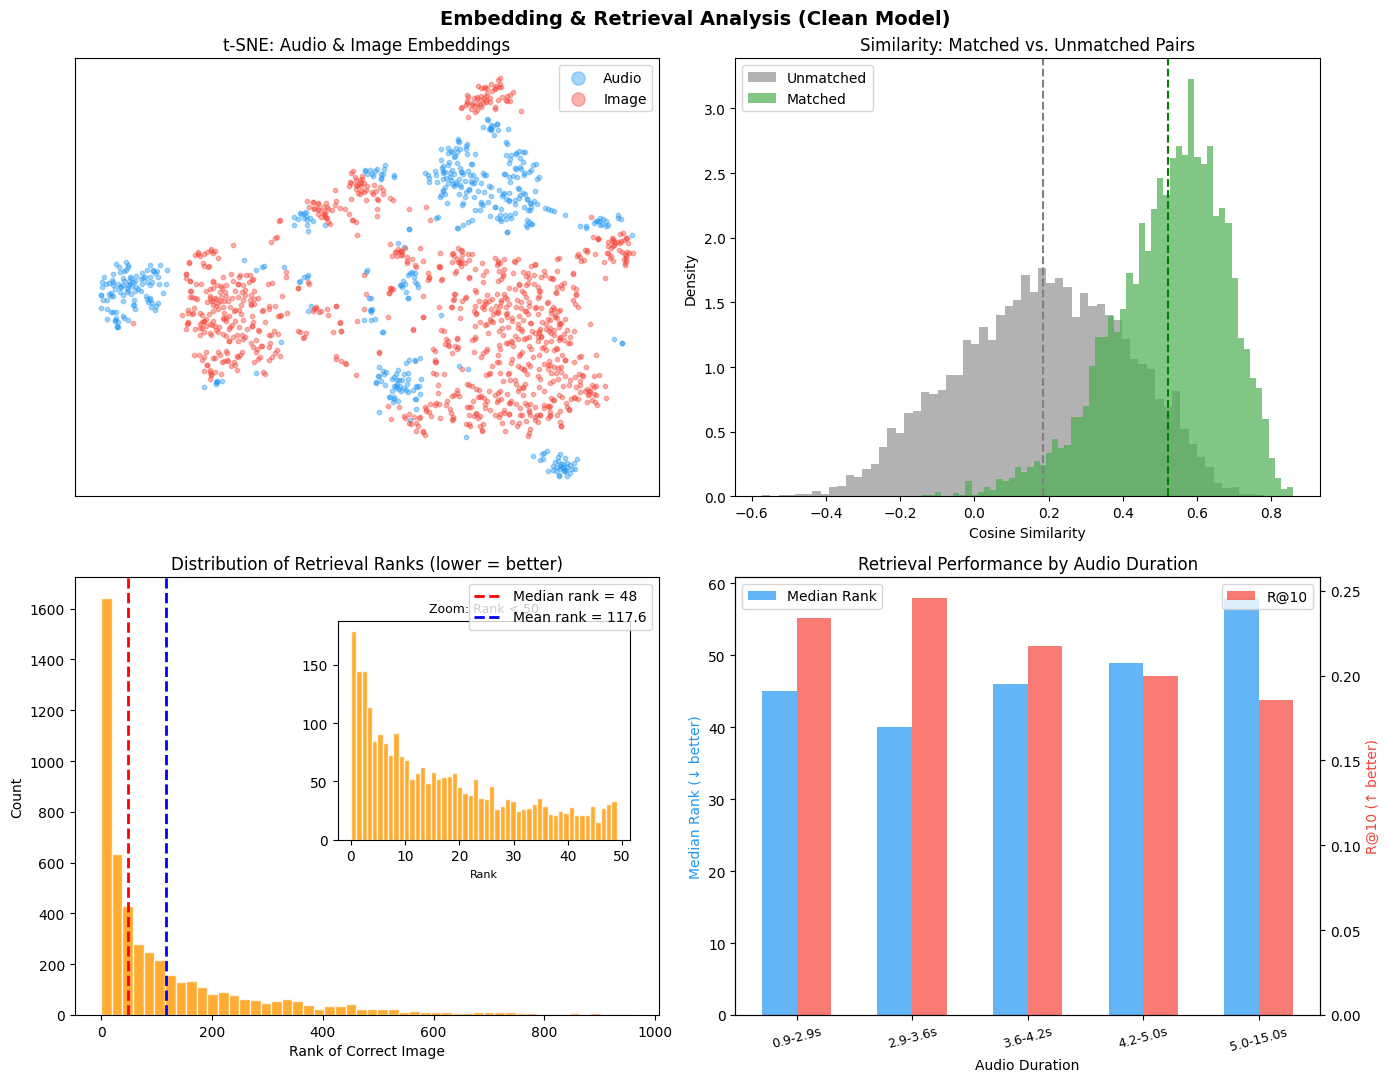


Similarity separation:  matched mean = 0.5224,  unmatched mean = 0.1841,  gap = 0.3383
Rank stats:  median = 48,  mean = 117.6,  % in top-10 = 21.6%,  % in top-50 = 51.0%
Audio duration range: 0.9s – 15.0s  (mean 4.0s)


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ── 1. t-SNE: joint audio + image embedding space ──
ax = axes[0, 0]
# Subsample for t-SNE speed: 500 audio + all 1000 images
np.random.seed(SEED)
sub_idx = np.random.choice(len(audio_embs), 500, replace=False)
combined = torch.cat([audio_embs[sub_idx], img_embs], dim=0).numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
proj = tsne.fit_transform(combined)

n_a = len(sub_idx)
ax.scatter(proj[:n_a, 0], proj[:n_a, 1], c='#2196F3', alpha=0.4, s=10, label='Audio')
ax.scatter(proj[n_a:, 0], proj[n_a:, 1], c='#F44336', alpha=0.4, s=10, label='Image')
ax.set_title('t-SNE: Audio & Image Embeddings')
ax.legend(markerscale=3)
ax.set_xticks([]); ax.set_yticks([])

# ── 2. Cosine similarity distributions ──
ax = axes[0, 1]
# Matched similarities (diagonal-like: each audio with its correct image)
matched_sims = []
for i, img_name in enumerate(img_labels):
    matched_sims.append(sim[i, img2idx[img_name]].item())
matched_sims = np.array(matched_sims)

# Random unmatched similarities (sample 5000 random pairs)
np.random.seed(SEED)
rand_i = np.random.randint(0, sim.shape[0], 5000)
rand_j = np.random.randint(0, sim.shape[1], 5000)
unmatched_sims = sim[rand_i, rand_j].numpy()

ax.hist(unmatched_sims, bins=60, alpha=0.6, density=True, color='gray', label='Unmatched')
ax.hist(matched_sims, bins=60, alpha=0.7, density=True, color='#4CAF50', label='Matched')
ax.axvline(np.mean(matched_sims), color='green', linestyle='--', linewidth=1.5)
ax.axvline(np.mean(unmatched_sims), color='gray', linestyle='--', linewidth=1.5)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Density')
ax.set_title('Similarity: Matched vs. Unmatched Pairs')
ax.legend()

# ── 3. Rank distribution ──
ax = axes[1, 0]
ax.hist(ranks, bins=50, color='#FF9800', edgecolor='white', alpha=0.8)
ax.axvline(np.median(ranks), color='red', linestyle='--', linewidth=2,
           label=f'Median rank = {np.median(ranks):.0f}')
ax.axvline(np.mean(ranks), color='blue', linestyle='--', linewidth=2,
           label=f'Mean rank = {np.mean(ranks):.1f}')
ax.set_xlabel('Rank of Correct Image')
ax.set_ylabel('Count')
ax.set_title('Distribution of Retrieval Ranks (lower = better)')
ax.legend()
# Inset: zoom on top-50
inset = ax.inset_axes([0.45, 0.4, 0.5, 0.5])
inset.hist(ranks[ranks < 50], bins=50, color='#FF9800', edgecolor='white', alpha=0.8)
inset.set_title('Zoom: Rank < 50', fontsize=9)
inset.set_xlabel('Rank', fontsize=8)

# ── 4. Audio duration vs. retrieval rank ──
ax = axes[1, 1]
# Bin durations into quintiles
dur_seconds = durations * 512 / 16000  # frames → seconds (hop=512, sr=16k)
bins_dur = np.percentile(dur_seconds, [0, 20, 40, 60, 80, 100])
bin_labels = []
bin_median_ranks = []
bin_r10 = []
for b in range(len(bins_dur) - 1):
    mask = (dur_seconds >= bins_dur[b]) & (dur_seconds < bins_dur[b+1] + 0.01)
    label = f"{bins_dur[b]:.1f}-{bins_dur[b+1]:.1f}s"
    bin_labels.append(label)
    bin_median_ranks.append(np.median(ranks[mask]))
    bin_r10.append(np.mean(ranks[mask] < 10))

color1 = '#2196F3'
color2 = '#F44336'
ax2 = ax.twinx()
x_pos = np.arange(len(bin_labels))
ax.bar(x_pos - 0.15, bin_median_ranks, 0.3, color=color1, alpha=0.7, label='Median Rank')
ax2.bar(x_pos + 0.15, bin_r10, 0.3, color=color2, alpha=0.7, label='R@10')
ax.set_xticks(x_pos)
ax.set_xticklabels(bin_labels, rotation=15, fontsize=9)
ax.set_xlabel('Audio Duration')
ax.set_ylabel('Median Rank (↓ better)', color=color1)
ax2.set_ylabel('R@10 (↑ better)', color=color2)
ax.set_title('Retrieval Performance by Audio Duration')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.suptitle('Embedding & Retrieval Analysis (Clean Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary stats ──
print(f"\nSimilarity separation:  matched mean = {np.mean(matched_sims):.4f},  "
      f"unmatched mean = {np.mean(unmatched_sims):.4f},  "
      f"gap = {np.mean(matched_sims) - np.mean(unmatched_sims):.4f}")
print(f"Rank stats:  median = {np.median(ranks):.0f},  mean = {np.mean(ranks):.1f},  "
      f"% in top-10 = {100*np.mean(ranks < 10):.1f}%,  "
      f"% in top-50 = {100*np.mean(ranks < 50):.1f}%")
print(f"Audio duration range: {dur_seconds.min():.1f}s – {dur_seconds.max():.1f}s  "
      f"(mean {dur_seconds.mean():.1f}s)")